In [1]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
from data_selector import Data_selector
from feature_adder import Feature_adder
from feature_selector import Feature_selector
from logs.logger import CustomLogger
from models import Random_Forest, Linear, Polynomial, XGBoost, LinearL1

logger = CustomLogger(name="model_main", log_file_name='model_main.log').get_logger()


def add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False, write_on_csv=False,num=5):
    csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")
    csv_semi_write_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

    if read_from_integrated:
        df = pd.read_csv(csv_read_path, encoding='utf-8')
        feature_adder = Feature_adder(df)
        feature_adder.create_feature_with_delay("temperature", num)
        feature_adder.filter1()
        feature_adder.filter2(l_min=l_min, max_diff=max_diff)
        feature_adder.filter3(f"temperature_with_{num}_delay", c_thresh=c_thresh,plot_pearsons_hist=True)
        df = feature_adder.df
        if write_on_csv:
            df.to_csv(csv_semi_write_path, index=False)
    else:
        df = pd.read_csv(csv_semi_write_path, encoding='utf-8')

    return df

2025-09-01 18:31:14 - feature_adder - INFO - 29.94% of rows have been chosen by filter1
2025-09-01 18:32:06 - feature_adder - INFO - 71.81% of rows have been chosen by filter2
2025-09-01 18:32:48 - feature_adder - INFO - 32.49% of rows have been chosen by filter3


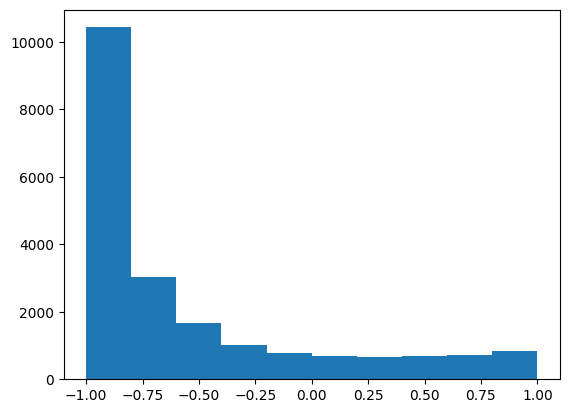

In [2]:
write_predictions = False
l_min = 4
max_diff = 3
c_thresh = 0.9
csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
feature_adder = Feature_adder(df)
feature_adder.create_feature_with_delay("temperature", 4)
feature_adder.filter1()
feature_adder.filter2(l_min=l_min, max_diff=max_diff)
feature_adder.filter3(f"temperature_with_{4}_delay", c_thresh=c_thresh,plot_pearsons_hist=True)

In [ ]:
write_predictions = False
l_min = 4
max_diff = 3
c_thresh = 0.9
csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
feature_adder = Feature_adder(df)
feature_adder.create_feature_with_delay("temperature", 5)
feature_adder.filter1()
feature_adder.filter2(l_min=l_min, max_diff=max_diff)
feature_adder.filter3(f"temperature_with_{5}_delay", c_thresh=c_thresh,plot_pearsons_hist=True)

In [3]:
feature_adder.create_feature_with_delay("temperature", 5)
feature_adder.filter3(f"temperature_with_{5}_delay", c_thresh=c_thresh,plot_pearsons_hist=True)

C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: x and y must have length at least 2.